# Part 1 - Data loading through model saving

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn torch

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('jigsaw-unintended-bias-train.csv')

df['toxic_binary'] = (df['toxic'] >= 0.5).astype(int)

df_toxic = df[df['toxic_binary'] == 1]
df_nontoxic = df[df['toxic_binary'] == 0]
n_toxic = int(100000 * (len(df_toxic) / len(df)))
n_nontoxic = 100000 - n_toxic

train_toxic = df_toxic.sample(n=min(n_toxic, len(df_toxic)), random_state=42)
train_nontoxic = df_nontoxic.sample(n=n_nontoxic, random_state=42)
train_df = pd.concat([train_toxic, train_nontoxic]).sample(frac=1, random_state=42)

eval_toxic = df_toxic.drop(train_toxic.index).sample(n=min(int(20000 * 0.08), len(df_toxic)-len(train_toxic)), random_state=42)
eval_nontoxic = df_nontoxic.drop(train_nontoxic.index).sample(n=20000 - len(eval_toxic), random_state=42)

eval_df = pd.concat([eval_toxic, eval_nontoxic]).sample(frac=1, random_state=42)

print(f"Training set: {len(train_df)} rows, {train_df['toxic_binary'].mean():.2%} toxic")
print(f"Evaluation set: {len(eval_df)} rows, {eval_df['toxic_binary'].mean():.2%} toxic")

Training set: 100000 rows, 8.00% toxic
Evaluation set: 20000 rows, 8.00% toxic


In [4]:
print("DATA VERIFICATION")
print(f"\n1. Total columns: {len(train_df.columns)}")
print(f"   Column names: {train_df.columns.tolist()}")

key_columns = ['comment_text', 'toxic', 'toxic_binary', 'black', 'white']
print(f"\n2. Key columns present:")
for col in key_columns:
    if col in train_df.columns:
        print(f"   {col}")
    else:
        print(f"   {col} MISSING")

print(f"\n3. Data types of key columns:")
for col in key_columns:
    if col in train_df.columns:
        print(f"   {col}: {train_df[col].dtype}")

print(f"\n4. Missing values in training set:")
for col in key_columns:
    if col in train_df.columns:
        missing = train_df[col].isnull().sum()
        if missing > 0:
            print(f"   {col}: {missing} missing values")
        else:
            print(f"   {col}: No missing values")

print(f"\n5. Sample comments from training set:")
print(f"\n   Example 1:")
print(f"   Comment: {train_df['comment_text'].iloc[0][:200]}...")
print(f"   Toxic: {train_df['toxic_binary'].iloc[0]}")
print(f"   Black identity score: {train_df['black'].iloc[0] if 'black' in train_df.columns else 'N/A'}")
print(f"   White identity score: {train_df['white'].iloc[0] if 'white' in train_df.columns else 'N/A'}")

DATA VERIFICATION

1. Total columns: 46
   Column names: ['id', 'comment_text', 'toxic', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability', 'jewish', 'latino', 'male', 'muslim', 'other_disability', 'other_gender', 'other_race_or_ethnicity', 'other_religion', 'other_sexual_orientation', 'physical_disability', 'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree', 'sexual_explicit', 'identity_annotator_count', 'toxicity_annotator_count', 'toxic_binary']

2. Key columns present:
   comment_text
   toxic
   toxic_binary
   black
   white

3. Data types of key columns:
   comment_text: object
   toxic: float64
   toxic_binary: int64
   black: float64
   white: float64

4. Missing values in tr

In [5]:
print("HANDLING MISSING IDENTITY VALUES")

print("\n1. Missing values BEFORE fixing:")
print(f"   Training set - black missing: {train_df['black'].isnull().sum():,} / {len(train_df):,}")
print(f"   Training set - white missing: {train_df['white'].isnull().sum():,} / {len(train_df):,}")
print(f"   Evaluation set - black missing: {eval_df['black'].isnull().sum():,} / {len(eval_df):,}")
print(f"   Evaluation set - white missing: {eval_df['white'].isnull().sum():,} / {len(eval_df):,}")

print("\n2. Filling missing values with 0 (no identity association)...")
train_df['black'] = train_df['black'].fillna(0)
train_df['white'] = train_df['white'].fillna(0)
eval_df['black'] = eval_df['black'].fillna(0)
eval_df['white'] = eval_df['white'].fillna(0)

print("\n3. Missing values AFTER fixing:")
print(f"   Training set - black missing: {train_df['black'].isnull().sum():,}")
print(f"   Training set - white missing: {train_df['white'].isnull().sum():,}")
print(f"   Evaluation set - black missing: {eval_df['black'].isnull().sum():,}")
print(f"   Evaluation set - white missing: {eval_df['white'].isnull().sum():,}")

print("\n4. Distribution after filling:")
print(f"   Training - black >= 0.5: {(train_df['black'] >= 0.5).sum():,} rows ({(train_df['black'] >= 0.5).mean():.2%})")
print(f"   Training - white >= 0.5: {(train_df['white'] >= 0.5).sum():,} rows ({(train_df['white'] >= 0.5).mean():.2%})")
print(f"   Evaluation - black >= 0.5: {(eval_df['black'] >= 0.5).sum():,} rows ({(eval_df['black'] >= 0.5).mean():.2%})")
print(f"   Evaluation - white >= 0.5: {(eval_df['white'] >= 0.5).sum():,} rows ({(eval_df['white'] >= 0.5).mean():.2%})")

train_df.to_csv('train_subset_cleaned.csv', index=False)
eval_df.to_csv('eval_subset_cleaned.csv', index=False)
print("\n5. Saved cleaned datasets to CSV files")

HANDLING MISSING IDENTITY VALUES

1. Missing values BEFORE fixing:
   Training set - black missing: 77,339 / 100,000
   Training set - white missing: 77,339 / 100,000
   Evaluation set - black missing: 15,444 / 20,000
   Evaluation set - white missing: 15,444 / 20,000

2. Filling missing values with 0 (no identity association)...

3. Missing values AFTER fixing:
   Training set - black missing: 0
   Training set - white missing: 0
   Evaluation set - black missing: 0
   Evaluation set - white missing: 0

4. Distribution after filling:
   Training - black >= 0.5: 747 rows (0.75%)
   Training - white >= 0.5: 1,390 rows (1.39%)
   Evaluation - black >= 0.5: 178 rows (0.89%)
   Evaluation - white >= 0.5: 271 rows (1.35%)

5. Saved cleaned datasets to CSV files


In [6]:
print("SETTING UP MODEL TRAINING ENVIRONMENT")

import torch
import pandas as pd
import numpy as np
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print(f"\n1. GPU Status:")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print(f"\n2. Loading cleaned datasets...")
train_df = pd.read_csv('train_subset_cleaned.csv')
eval_df = pd.read_csv('eval_subset_cleaned.csv')
print(f"   Training set: {len(train_df):,} rows")
print(f"   Evaluation set: {len(eval_df):,} rows")
print(f"   Training toxic %: {train_df['toxic_binary'].mean():.2%}")
print(f"   Evaluation toxic %: {eval_df['toxic_binary'].mean():.2%}")

print(f"\n3. Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print(f"   Tokenizer loaded successfully")

sample_text = train_df['comment_text'].iloc[0]
tokens = tokenizer(sample_text, truncation=True, max_length=128)
print(f"\n4. Tokenizer test:")
print(f"   Sample text: {sample_text[:100]}...")
print(f"   Token count: {len(tokens['input_ids'])}")

SETTING UP MODEL TRAINING ENVIRONMENT

1. GPU Status:
   CUDA available: True
   GPU Device: Tesla T4
   GPU Memory: 14.6 GB

2. Loading cleaned datasets...
   Training set: 100,000 rows
   Evaluation set: 20,000 rows
   Training toxic %: 8.00%
   Evaluation toxic %: 8.00%

3. Loading DistilBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Tokenizer loaded successfully

4. Tokenizer test:
   Sample text: There's no end in sight to the priest shortage, anywhere in this country.   Foreign "rent a priests"...
   Token count: 92


In [7]:
print("PREPARING DATASETS FOR TRAINING")

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("\n1. Converting to HuggingFace Dataset format...")
train_hf = Dataset.from_dict({
    'text': train_df['comment_text'].tolist(),
    'label': train_df['toxic_binary'].tolist()
})

eval_hf = Dataset.from_dict({
    'text': eval_df['comment_text'].tolist(),
    'label': eval_df['toxic_binary'].tolist()
})

print(f"   Training dataset: {len(train_hf):,} examples")
print(f"   Evaluation dataset: {len(eval_hf):,} examples")

print("\n2. Tokenizing datasets (this may take 2-3 minutes)...")
train_tokenized = train_hf.map(tokenize_function, batched=True, batch_size=1000)
eval_tokenized = eval_hf.map(tokenize_function, batched=True, batch_size=1000)

print("   Tokenization complete!")

print("\n3. Setting PyTorch format...")
train_tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
eval_tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("   Format set successfully!")

print("\n4. Verifying data format:")
sample = train_tokenized[0]
print(f"   input_ids shape: {sample['input_ids'].shape}")
print(f"   attention_mask shape: {sample['attention_mask'].shape}")
print(f"   label: {sample['label']}")
print(f"   First 20 tokens: {sample['input_ids'][:20].tolist()}")

print("\n5. Class distribution in tokenized datasets:")
train_labels = [train_tokenized[i]['label'] for i in range(min(1000, len(train_tokenized)))]
print(f"   Training (sample of 1000): {sum(train_labels)} toxic ({sum(train_labels)/len(train_labels):.2%})")

PREPARING DATASETS FOR TRAINING

1. Converting to HuggingFace Dataset format...
   Training dataset: 100,000 examples
   Evaluation dataset: 20,000 examples

2. Tokenizing datasets (this may take 2-3 minutes)...


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

   Tokenization complete!

3. Setting PyTorch format...
   Format set successfully!

4. Verifying data format:
   input_ids shape: torch.Size([128])
   attention_mask shape: torch.Size([128])
   label: 0
   First 20 tokens: [101, 2045, 1005, 1055, 2053, 2203, 1999, 4356, 2000, 1996, 5011, 15843, 1010, 5973, 1999, 2023, 2406, 1012, 3097, 1000]

5. Class distribution in tokenized datasets:
   Training (sample of 1000): 88 toxic (8.80%)


In [8]:
from scipy.special import softmax
print("LOADING DISTILBERT MODEL")

print("\n1. Loading DistilBERT model...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  # Binary classification
)

model = model.to('cuda')
print(f"   Model loaded and moved to GPU")
print(f"   Number of parameters: {model.num_parameters():,}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probs = softmax(logits, axis=-1)[:, 1]

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions),
        'recall': recall_score(labels, predictions),
        'auc': roc_auc_score(labels, probs)
    }


print("\n2. Configuring training arguments...")
training_args = TrainingArguments(
    output_dir='./distilbert_toxicity_model',
    num_train_epochs=3,                         # 3 epochs as specified
    per_device_train_batch_size=32,             # Batch size for training
    per_device_eval_batch_size=64,              # Batch size for evaluation
    warmup_steps=500,                           # Warmup steps
    weight_decay=0.01,                          # Weight decay
    learning_rate=2e-5,                         # Learning rate
    logging_dir='./logs',                       # Directory for logs
    logging_steps=100,                          # Log every 100 steps
    eval_strategy='epoch',                      # Evaluate at end of each epoch (FIXED)
    save_strategy='epoch',                      # Save at end of each epoch
    load_best_model_at_end=True,                # Load best model at end
    metric_for_best_model='f1_macro',           # Use F1 to select best model
    fp16=True,
    report_to='none',
)

print("\n3. Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    compute_metrics=compute_metrics,
)

print("\n4. Training configuration complete!")
print(f"   Training on {len(train_tokenized):,} samples")
print(f"   Evaluating on {len(eval_tokenized):,} samples")
print(f"   Total training steps: ~{len(train_tokenized) // 32 * 3}")
print("\n   Ready to train!")

LOADING DISTILBERT MODEL

1. Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


   Model loaded and moved to GPU
   Number of parameters: 66,955,010

2. Configuring training arguments...

3. Initializing Trainer...

4. Training configuration complete!
   Training on 100,000 samples
   Evaluating on 20,000 samples
   Total training steps: ~9375

   Ready to train!


In [9]:
print("STARTING MODEL TRAINING")

trainer.train()

print("\nTraining complete!")

print("\nSaving model...")
trainer.save_model('./distilbert_toxicity_model_final')
tokenizer.save_pretrained('./distilbert_toxicity_model_final')
print("Model saved to './distilbert_toxicity_model_final'")

STARTING MODEL TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall,Auc
1,0.132131,0.137296,0.947500,0.808580,0.701909,0.597500,0.948940
2,0.115535,0.141857,0.950400,0.810773,0.749180,0.571250,0.950836
3,0.080477,0.180721,0.946050,0.814144,0.667956,0.647500,0.946254


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete!

Saving model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './distilbert_toxicity_model_final'


In [10]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

print("PART 1: BASELINE CLASSIFIER EVALUATION")

print("\n1. Getting predictions on evaluation set...")
predictions = trainer.predict(eval_tokenized)
logits = predictions.predictions
probs = softmax(logits, axis=-1)[:, 1]
preds = np.argmax(logits, axis=-1)
labels = predictions.label_ids

accuracy = accuracy_score(labels, preds)
f1_macro = f1_score(labels, preds, average='macro')
f1_binary = f1_score(labels, preds, average='binary')
precision = precision_score(labels, preds)
recall = recall_score(labels, preds)
auc = roc_auc_score(labels, probs)

print("\n2. Evaluation Metrics (at threshold 0.5):")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy:.2%})")
print(f"   F1 (macro): {f1_macro:.4f}")
print(f"   F1 (binary): {f1_binary:.4f}")
print(f"   Precision:  {precision:.4f}")
print(f"   Recall:     {recall:.4f}")
print(f"   AUC-ROC:    {auc:.4f}")

print("\n3. Confusion Matrix:")
cm = confusion_matrix(labels, preds)
print(f"                 Predicted")
print(f"                 Non-Toxic  Toxic")
print(f"   Actual Non-Toxic:  {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"   Actual Toxic:      {cm[1,0]:5d}   {cm[1,1]:5d}")

tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (tp + fn)
tnr = tn / (tn + fp)

print(f"\n   True Positive Rate (Recall): {tpr:.4f}")
print(f"   False Positive Rate: {fpr:.4f}")
print(f"   False Negative Rate: {fnr:.4f}")
print(f"   True Negative Rate: {tnr:.4f}")

print("\n4. Finding optimal threshold (based on F1 score):")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"\n   Threshold | F1 Score | Precision | Recall")
print(f"   {'-'*45}")

best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    preds_thresh = (probs >= threshold).astype(int)
    f1 = f1_score(labels, preds_thresh)
    prec = precision_score(labels, preds_thresh)
    rec = recall_score(labels, preds_thresh)
    print(f"      {threshold:.1f}     |   {f1:.4f}   |   {prec:.4f}   |   {rec:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest F1 score: {best_f1:.4f} at threshold = {best_threshold}")

print("THRESHOLD JUSTIFICATION")

print(f"\nRecommended operating threshold: {best_threshold}")
print(f"\nWhy this threshold?")
print(f"• At {best_threshold}, F1 score is {best_f1:.4f} (best balance of precision & recall)")
if best_threshold == 0.5:
    print("• 0.5 is the default balanced threshold")
    print("• Balances catching toxic content vs avoiding false positives")
elif best_threshold < 0.5:
    print("• Lower threshold catches more toxic content")
    print("• Increases recall but may increase false positives")
else:
    print("• Higher threshold reduces false positives")
    print("• Increases precision but may miss some toxic content")

print(f"\nFor this platform, we choose threshold = {best_threshold} because:")
if best_threshold <= 0.5:
    print("• Prioritizes catching harmful content over avoiding false positives")
    print("• Better for user safety, though some innocent users may be flagged")
else:
    print("• Prioritizes user experience over catching all toxic content")
    print("• Fewer false positives, but some toxic content may slip through")

PART 1: BASELINE CLASSIFIER EVALUATION

1. Getting predictions on evaluation set...



2. Evaluation Metrics (at threshold 0.5):
   Accuracy:  0.9460 (94.60%)
   F1 (macro): 0.8141
   F1 (binary): 0.6576
   Precision:  0.6680
   Recall:     0.6475
   AUC-ROC:    0.9463

3. Confusion Matrix:
                 Predicted
                 Non-Toxic  Toxic
   Actual Non-Toxic:  17885     515
   Actual Toxic:        564    1036

   True Positive Rate (Recall): 0.6475
   False Positive Rate: 0.0280
   False Negative Rate: 0.3525
   True Negative Rate: 0.9720

4. Finding optimal threshold (based on F1 score):

   Threshold | F1 Score | Precision | Recall
   ---------------------------------------------
      0.3     |   0.6531   |   0.6267   |   0.6819
      0.4     |   0.6551   |   0.6485   |   0.6619
      0.5     |   0.6576   |   0.6680   |   0.6475
      0.6     |   0.6593   |   0.6884   |   0.6325
      0.7     |   0.6541   |   0.7093   |   0.6069

Best F1 score: 0.6593 at threshold = 0.6
THRESHOLD JUSTIFICATION

Recommended operating threshold: 0.6

Why this threshold?
• A

GENERATING PLOTS


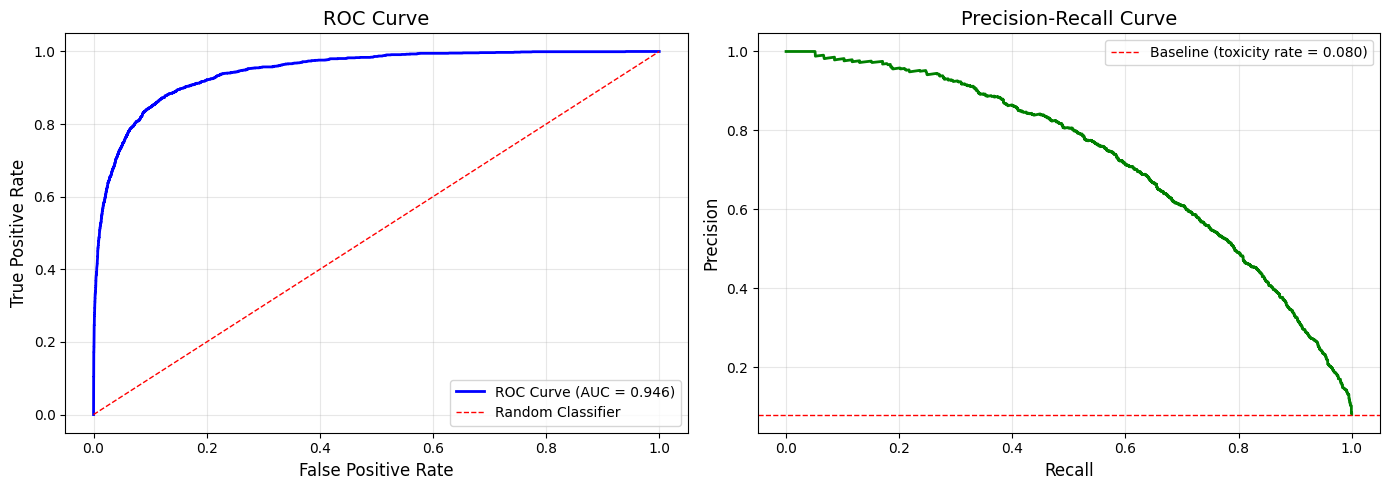


Plots saved as 'roc_pr_curves.png'


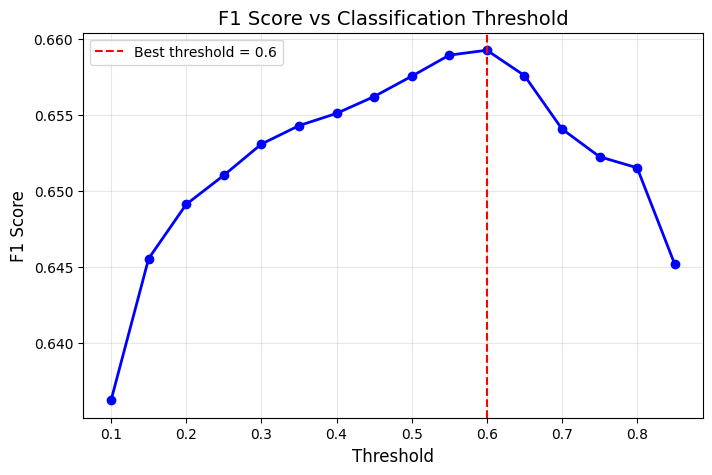


Best threshold = 0.6 with F1 = 0.6593


In [11]:
print("GENERATING PLOTS")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr_roc, tpr_roc, _ = roc_curve(labels, probs)
ax1.plot(fpr_roc, tpr_roc, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

precision_vals, recall_vals, _ = precision_recall_curve(labels, probs)
ax2.plot(recall_vals, precision_vals, 'g-', linewidth=2)
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.grid(True, alpha=0.3)

baseline = labels.mean()
ax2.axhline(y=baseline, color='r', linestyle='--', linewidth=1, label=f'Baseline (toxicity rate = {baseline:.3f})')
ax2.legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

print("\nPlots saved as 'roc_pr_curves.png'")

# Optional: F1 vs Threshold plot
plt.figure(figsize=(8, 5))
threshold_range = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for thresh in threshold_range:
    preds_thresh = (probs >= thresh).astype(int)
    f1_scores.append(f1_score(labels, preds_thresh))

plt.plot(threshold_range, f1_scores, 'bo-', linewidth=2)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Classification Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best threshold = {best_threshold}')
plt.legend()
plt.show()

print(f"\nBest threshold = {best_threshold} with F1 = {best_f1:.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r distilbert_toxicity_model_final /content/drive/MyDrive/

print("Model saved to Google Drive at: /content/drive/MyDrive/distilbert_toxicity_model_final")

!zip -r distilbert_model.zip distilbert_toxicity_model_final/
print("Model also saved as 'distilbert_model.zip' for download")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive at: /content/drive/MyDrive/distilbert_toxicity_model_final
  adding: distilbert_toxicity_model_final/ (stored 0%)
  adding: distilbert_toxicity_model_final/training_args.bin (deflated 53%)
  adding: distilbert_toxicity_model_final/model.safetensors